In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_excel('dados_cerveja_nota.xlsx')

In [9]:
df.head(5)

,id,cerveja,nota
0,1,1,0.75
1,2,1,3.00
2,3,2,1.75
3,4,3,1.75
4,5,4,4.20


In [10]:
df['aprovado'] = (df['nota'] > 5).astype(int) #Transformo o True e False em 0 e 1, facilitando o trabalho com ml e cálculos depois

In [11]:
df.shape

(15, 4)

In [12]:
df.sort_values('nota', ascending=True)

,id,cerveja,nota,aprovado
0,1,1,0.75,0
2,3,2,1.75,0
3,4,3,1.75,0
6,7,5,2.90,0
1,2,1,3.00,0
4,5,4,4.20,0
7,8,6,6.20,1
9,10,7,6.20,1
5,6,4,6.50,1
8,9,6,7.00,1


Text(0, 0.5, 'Aprovado')

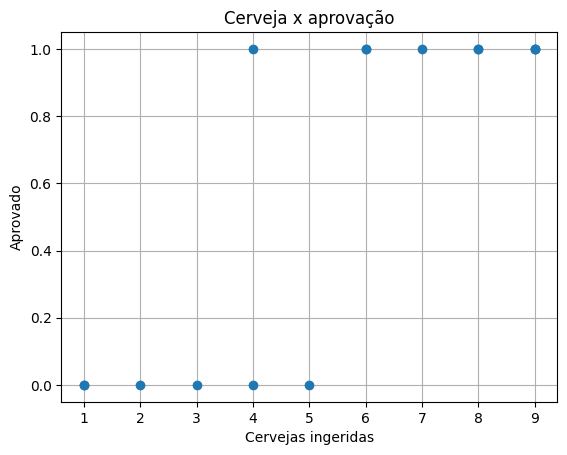

In [13]:
plt.plot(df['cerveja'], df['aprovado'], 'o')
plt.grid(True)
plt.title('Cerveja x aprovação')
plt.xlabel('Cervejas ingeridas')
plt.ylabel('Aprovado')

#Regressão logística

In [14]:
from sklearn import linear_model

In [15]:
reg = linear_model.LogisticRegression(penalty=None, fit_intercept=True)

In [16]:
reg.fit(df[['cerveja']], df['aprovado']) #Uso colchetes duplos no df[cerveja] pois os modelos sempre esperam receber uma matriz, mesmo que
#só tenha uma coluna.

LogisticRegression(penalty=None)

In [17]:
reg_predict = reg.predict(df[['cerveja']].drop_duplicates())

In [18]:
reg_predict

array([0, 0, 0, 0, 1, 1, 1, 1, 1])

Text(0, 0.5, 'Aprovado')

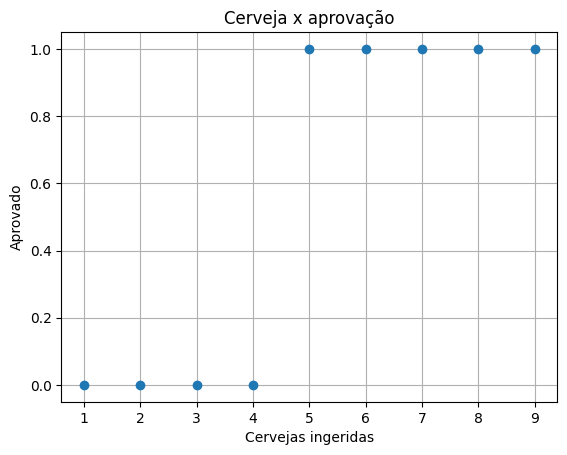

In [19]:
plt.plot(df['cerveja'].drop_duplicates(), reg_predict, 'o') #Plotando as predições das cervejas
plt.grid(True)
plt.title('Cerveja x aprovação')
plt.xlabel('Cervejas ingeridas')
plt.ylabel('Aprovado')

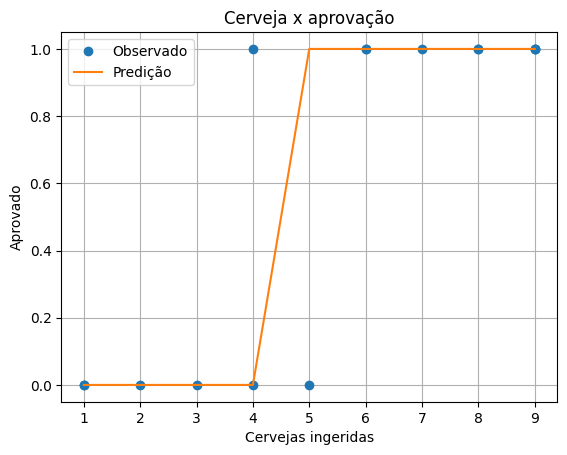

In [20]:
#Comparando os meus dados reais com as previsões
plt.plot(df['cerveja'], df['aprovado'], 'o')
plt.plot(df['cerveja'].drop_duplicates(), reg_predict)
plt.grid(True)
plt.title('Cerveja x aprovação')
plt.xlabel('Cervejas ingeridas')
plt.ylabel('Aprovado')
plt.legend(['Observado','Predição'])

In [21]:
reg_proba = reg.predict_proba(df[['cerveja']].drop_duplicates())[:,1]
# O comando [:,1] realiza o slicing (fatiamento). O predict_proba nos
# retorna um array numpy (matriz de dados). Para acessarmos partes desses dados,  usamos colchetes no formato [linhas, colunas]. O ':' sig-
# nifica que queremos acessar todas as linhas dessa matriz na coluna 1. Então o que escrevemos [:,1] siginifica [todas as inhas, coluna 1]

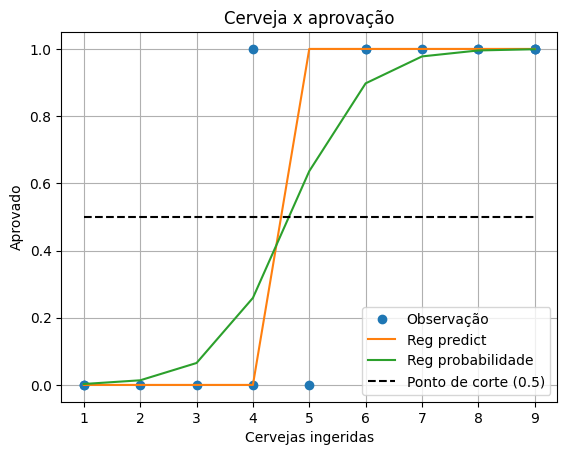

In [22]:
#Comparando os meus dados reais com as previsões
plt.plot(df['cerveja'], df['aprovado'], 'o')
plt.plot(df['cerveja'].drop_duplicates(), reg_predict)
plt.plot(df['cerveja'].drop_duplicates(), reg_proba)
plt.grid(True)
plt.title('Cerveja x aprovação')
plt.xlabel('Cervejas ingeridas')
plt.ylabel('Aprovado')

plt.hlines(0.5, xmin=1, xmax=9, colors='black', linestyles="--") #Traçando uma linha horizontal. Indico o valor que ela está em y, e coloco
#o vmin (ponto de x que ela começa) e o vmax (ponto de x que ela termina). Tenho o vlines, que faz a mesma coisa mas na vertical

plt.legend(['Observação','Reg predict','Reg probabilidade','Ponto de corte (0.5)'])

No gráfico acima podemos ver como o modelo classifica entre 0 e 1 dependendo da probabilidade. Tudo que a probabilidade de ser 1 passa de 0.5, o modelo classifica como y = 1. Podemos observar perfeitamente isso no ponto x=5, onde mesmo não tendo sido aprovado, o modelo calculou a probabilidade de y=1 maior que 0.5, e a observação foi classificada como aprovada

#Árvore de Decisão

In [23]:
from sklearn import tree

In [24]:
full_tree = tree.DecisionTreeClassifier(random_state=42)
full_tree.fit(df[['cerveja']], df['aprovado'])
tree_predicts = full_tree.predict(df[['cerveja']].drop_duplicates())
tree_proba = full_tree.predict_proba(df[['cerveja']].drop_duplicates())[:,1]

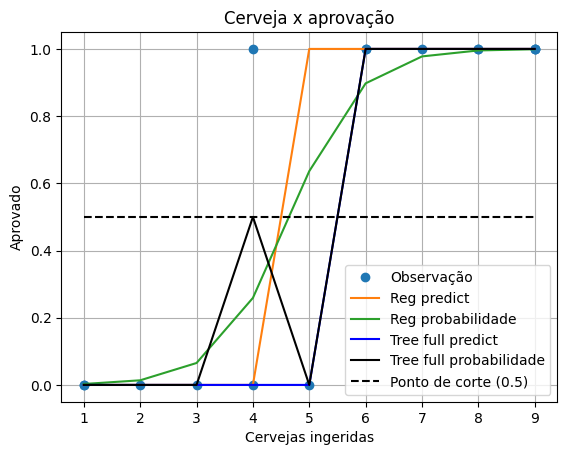

In [25]:
plt.plot(df['cerveja'], df['aprovado'], 'o')
plt.plot(df['cerveja'].drop_duplicates(), reg_predict)
plt.plot(df['cerveja'].drop_duplicates(), reg_proba)

plt.plot(df['cerveja'].drop_duplicates(), tree_predicts, color="blue")
plt.plot(df['cerveja'].drop_duplicates(), tree_proba, color="Black")

plt.grid(True)
plt.title('Cerveja x aprovação')
plt.xlabel('Cervejas ingeridas')
plt.ylabel('Aprovado')

plt.hlines(0.5, xmin=1, xmax=9, colors='black', linestyles="--") #Traçando uma linha horizontal. Indico o valor que ela está em y, e coloco
#o vmin (ponto de x que ela começa) e o vmax (ponto de x que ela termina). Tenho o vlines, que faz a mesma coisa mas na vertical

plt.legend(['Observação','Reg predict','Reg probabilidade','Tree full predict','Tree full probabilidade','Ponto de corte (0.5)'])

Percebemos que a àrvore de decisão completa, colocou a probabilidade como 0.5 para 4 cervejas, pois tivemos um aprovado e 1 não aprovado nessa faixa. É perceptível uma abruptez da linha para dados que tem uma relação positiva clara.

#Árvore com 2 nós 4 folhas

In [26]:
tree_d2 = tree.DecisionTreeClassifier(random_state=42, max_depth=2)
tree_d2.fit(df[['cerveja']], df['aprovado'])
d2_predicts = tree_d2.predict(df[['cerveja']].drop_duplicates())
d2_proba = tree_d2.predict_proba(df[['cerveja']].drop_duplicates())[:,1]

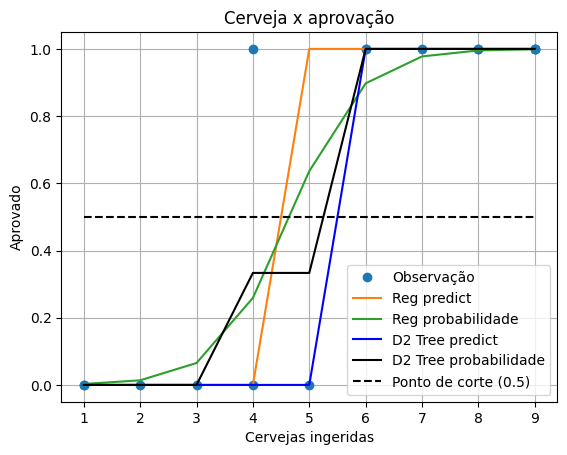

In [27]:
plt.plot(df['cerveja'], df['aprovado'], 'o')
plt.plot(df['cerveja'].drop_duplicates(), reg_predict)
plt.plot(df['cerveja'].drop_duplicates(), reg_proba)

plt.plot(df['cerveja'].drop_duplicates(), d2_predicts, color="blue")
plt.plot(df['cerveja'].drop_duplicates(), d2_proba, color="Black")

plt.grid(True)
plt.title('Cerveja x aprovação')
plt.xlabel('Cervejas ingeridas')
plt.ylabel('Aprovado')

plt.hlines(0.5, xmin=1, xmax=9, colors='black', linestyles="--") #Traçando uma linha horizontal. Indico o valor que ela está em y, e coloco
#o vmin (ponto de x que ela começa) e o vmax (ponto de x que ela termina). Tenho o vlines, que faz a mesma coisa mas na vertical

plt.legend(['Observação','Reg predict','Reg probabilidade','D2 Tree predict','D2 Tree probabilidade','Ponto de corte (0.5)'])

Agora a árvore de decisão com 2 de profundidade já apresenta uma fluídez na probabilidade, apresentando um crescimento fluído, deixando de classificar x = 4 com probabilidade 0.5 por conta das duas classes distintas nos dados.

**Aqui também fica perceptível como a Árvore se mostrou melhor em capturar o padrão de aprovação, pois a nossa árvore coloca quem tem mais 6 cervejas com mais probabilidade de ser aprovado do que a Regressão Logística**

#Naive Bayes

In [28]:
from sklearn import naive_bayes

In [29]:
nb = naive_bayes.GaussianNB()
nb.fit(df[['cerveja']], df['aprovado'])
nb_predict = nb.predict(df[['cerveja']].drop_duplicates())
nb_proba = nb.predict_proba(df[['cerveja']].drop_duplicates())[:,1]

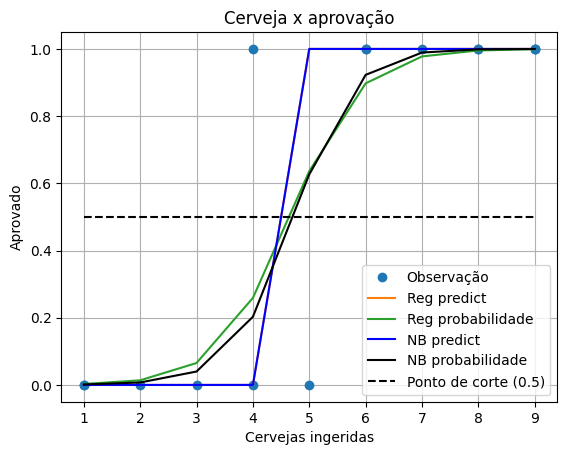

In [30]:
plt.plot(df['cerveja'], df['aprovado'], 'o')
plt.plot(df['cerveja'].drop_duplicates(), reg_predict)
plt.plot(df['cerveja'].drop_duplicates(), reg_proba)

plt.plot(df['cerveja'].drop_duplicates(), nb_predict, color="blue")
plt.plot(df['cerveja'].drop_duplicates(), nb_proba, color="Black")

plt.grid(True)
plt.title('Cerveja x aprovação')
plt.xlabel('Cervejas ingeridas')
plt.ylabel('Aprovado')

plt.hlines(0.5, xmin=1, xmax=9, colors='black', linestyles="--") #Traçando uma linha horizontal. Indico o valor que ela está em y, e coloco
#o vmin (ponto de x que ela começa) e o vmax (ponto de x que ela termina). Tenho o vlines, que faz a mesma coisa mas na vertical

plt.legend(['Observação','Reg predict','Reg probabilidade','NB predict','NB probabilidade','Ponto de corte (0.5)'])

Aqui vemos que o Naive Bayes teve as mesmas predições que a Regressão Logística, mas quando olhamos para as probabilidades, vemos que o Naive Bayes teve probabilidade melhores, com menores probabilidades para quem tem menos que 5 cervejas, e maiores probabilidades para quem tem mais de 5, mostrando um ajuste melhor.

Esse tipo de diferença, nesse cenário, faria o NB performar melhor que a RL em relação a métricas como ROC.

#Comparando todas as probabildades e classificações

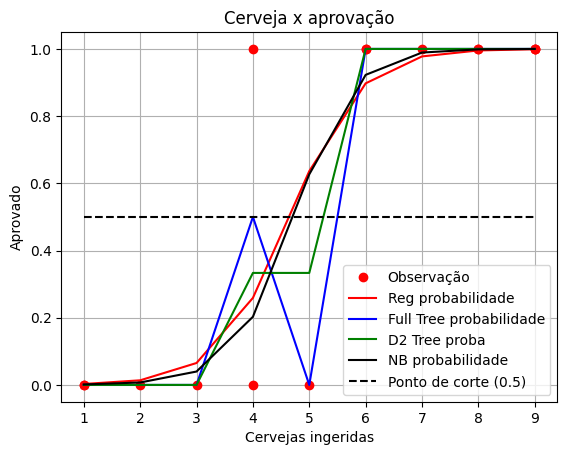

In [31]:
plt.plot(df['cerveja'], df['aprovado'], 'o', color='red')
plt.plot(df['cerveja'].drop_duplicates(), reg_proba, color='red')
plt.plot(df['cerveja'].drop_duplicates(), tree_proba, color="blue")
plt.plot(df['cerveja'].drop_duplicates(), d2_proba, color="green")
plt.plot(df['cerveja'].drop_duplicates(), nb_proba, color="Black")

plt.grid(True)
plt.title('Cerveja x aprovação')
plt.xlabel('Cervejas ingeridas')
plt.ylabel('Aprovado')

plt.hlines(0.5, xmin=1, xmax=9, colors='black', linestyles="--") #Traçando uma linha horizontal. Indico o valor que ela está em y, e coloco
#o vmin (ponto de x que ela começa) e o vmax (ponto de x que ela termina). Tenho o vlines, que faz a mesma coisa mas na vertical

plt.legend(['Observação','Reg probabilidade','Full Tree probabilidade','D2 Tree proba','NB probabilidade','Ponto de corte (0.5)'])

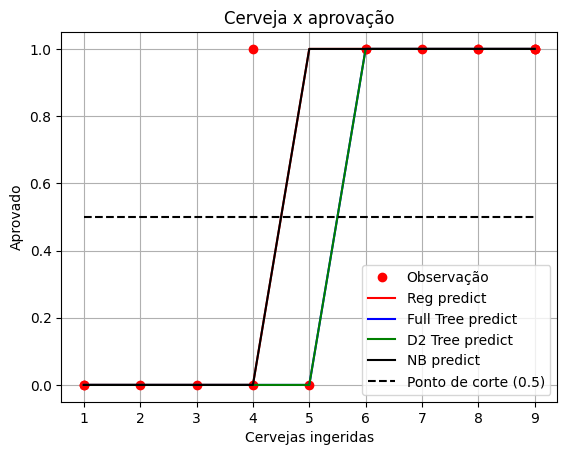

In [32]:
plt.plot(df['cerveja'], df['aprovado'], 'o', color='red')
plt.plot(df['cerveja'].drop_duplicates(), reg_predict, color='red')
plt.plot(df['cerveja'].drop_duplicates(), tree_predicts, color="blue")
plt.plot(df['cerveja'].drop_duplicates(), d2_predicts, color="green")
plt.plot(df['cerveja'].drop_duplicates(), nb_predict, color="Black")

plt.grid(True)
plt.title('Cerveja x aprovação')
plt.xlabel('Cervejas ingeridas')
plt.ylabel('Aprovado')

plt.hlines(0.5, xmin=1, xmax=9, colors='black', linestyles="--") #Traçando uma linha horizontal. Indico o valor que ela está em y, e coloco
#o vmin (ponto de x que ela começa) e o vmax (ponto de x que ela termina). Tenho o vlines, que faz a mesma coisa mas na vertical

plt.legend(['Observação','Reg predict','Full Tree predict','D2 Tree predict','NB predict','Ponto de corte (0.5)'])